Starting fit for all_data.csv (Optimized)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.0min


all_data importance list:
all_data 
                              importance
Features                               
Bwd Packet Length Std          0.381446
Destination Port               0.102285
Fwd Packet Length Std          0.009685
Flow IAT Min                   0.003358
Fwd Packet Length Max          0.002781
Flow IAT Mean                  0.000777
Flow IAT Std                   0.000691
Flow Packets/s                 0.000631
Fwd Packet Length Min          0.000519
Flow Bytes/s                   0.000433
Total Backward Packets         0.000278
Bwd Packet Length Max          0.000277
Flow IAT Max                   0.000272
Total Fwd Packets              0.000264
Flow Duration                  0.000221
Bwd Packet Length Mean         0.000172
Fwd Packet Length Mean         0.000138
Total Length of Bwd Packets    0.000132
Total Length of Fwd Packets    0.000128
Bwd Packet Length Min          0.000008 



all_data=["Bwd Packet Length Std","Destination Port","Fwd Packet Length Std","F

[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.7min finished


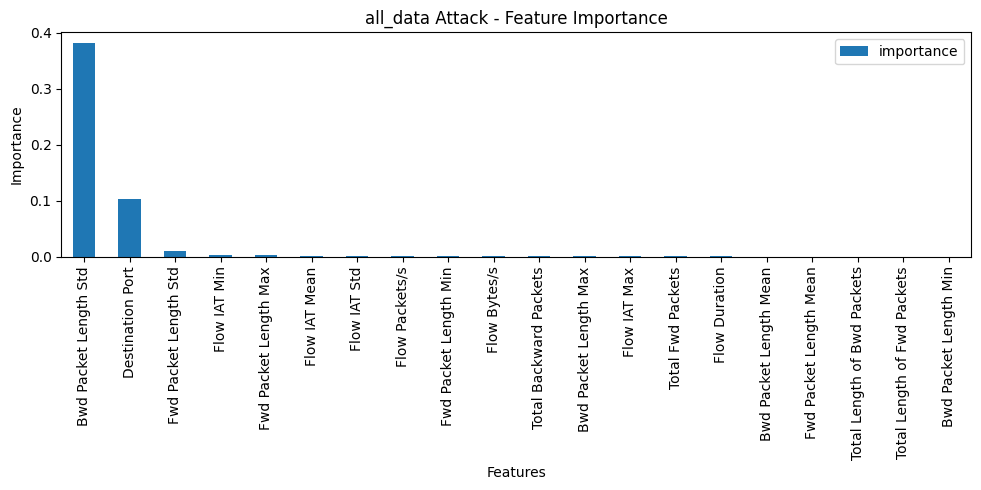

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import sklearn as sk
import time
seconds = time.time()

def folder(f_name): #this function creates a folder named "feaure_pics" in the program directory.
    try:
        if not os.path.exists(f_name):
            os.makedirs(f_name)
    except OSError:
        print ("The folder could not be created!")
        


csv_files = ["all_data.csv"]  # List of file names


main_labels = [
    "Destination Port", "Flow Duration", "Total Fwd Packets", "Total Backward Packets", 
    "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Fwd Packet Length Max",
    "Fwd Packet Length Min", "Fwd Packet Length Mean", "Fwd Packet Length Std", 
    "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean", 
    "Bwd Packet Length Std", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", 
    "Flow IAT Std", "Flow IAT Max", "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Mean", 
    "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Mean", 
    "Bwd IAT Std", "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", 
    "Fwd URG Flags", "Bwd URG Flags", "Fwd Header Length", "Bwd Header Length", 
    "Fwd Packets/s", "Bwd Packets/s", "Min Packet Length", "Max Packet Length", 
    "Packet Length Mean", "Packet Length Std", "Packet Length Variance", 
    "FIN Flag Count", "SYN Flag Count", "RST Flag Count", "PSH Flag Count", 
    "ACK Flag Count", "URG Flag Count", "CWE Flag Count", "ECE Flag Count", 
    "Down/Up Ratio", "Average Packet Size", "Avg Fwd Segment Size", 
    "Avg Bwd Segment Size", "Fwd Header Length.1", "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk", 
    "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", 
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", 
    "Subflow Bwd Bytes", "Init_Win_bytes_forward", "Init_Win_bytes_backward", 
    "act_data_pkt_fwd", "min_seg_size_forward", "Active Mean", "Active Std", 
    "Active Max", "Active Min", "Idle Mean", "Idle Std", "Idle Max", "Idle Min", 
    "label"  
]


ths = open("importance_list_all_data.csv", "w")
folder("./feaure_pics/")

for j in csv_files:
    df = pd.read_csv(j, usecols=main_labels)
    df = df.fillna(0)
    
    
    attack_or_not = [1 if i == "BENIGN" else 0 for i in df["label"]]
    df["label"] = attack_or_not

    
    y = df["label"].values
    del df["label"]  
    
    X = df.values
    X = np.float32(X)
    X[np.isnan(X)] = 0
    X[np.isinf(X)] = 0

    
    # Optimized Forest for 2.8M rows - Should finish in ~35-45 mins
    forest = sk.ensemble.RandomForestRegressor(
        n_estimators=50, 
        max_samples=0.2,   # Each tree sees 20% of the rows (huge memory win)
        max_depth=12,      # Keeps trees from getting stuck in complex loops
        n_jobs=-1,         # Uses all 21 of your threads
        random_state=0,
        verbose=1          # Shows you a progress bar so you know it's moving
    )
    
    print(f"Starting fit for {j} (Optimized)...")
    forest.fit(X, y)
    importances = forest.feature_importances_
    std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
    indices = np.argsort(importances)[::-1]
    
    refclasscol = list(df.columns.values)
    impor_bars = pd.DataFrame({'Features': refclasscol[0:20], 'importance': importances[0:20]})
    impor_bars = impor_bars.sort_values('importance', ascending=False).set_index('Features')
    
    
    plt.rcParams['figure.figsize'] = (10, 5)
    impor_bars.plot.bar()
    
    # Printing feature importance
    count = 0
    fea_ture = j[0:-4] + "=["
    for i in impor_bars.index:
        fea_ture = fea_ture + "\"" + str(i) + "\","
        count += 1
        if count == 5:
            fea_ture = fea_ture[0:-1] + "]"
            break

    print(j[0:-4], "importance list:")
    print(j[0:-4], "\n", impor_bars.head(20), "\n\n\n")
    print(fea_ture)
    
    plt.title(j[0:-4] + " Attack - Feature Importance")
    plt.ylabel('Importance')
    plt.savefig("./feaure_pics/" + j[0:-4] + ".pdf", bbox_inches='tight', orientation='portrait', format='pdf')
    
    ths.write(fea_ture)
    plt.tight_layout()
    
    print("-----------------------------------------------------------------------------------------------\n\n\n\n")

print("mission accomplished!")
print("Total operation time: = ", time.time() - seconds, "seconds")
ths.close()


In [3]:
ths = open("importance_list_all_data.csv", "w")

count = 0
fea_ture = "all_data=["
for i in impor_bars.index:
    fea_ture = fea_ture + "\"" + str(i) + "\","
    count += 1
    if count == 20:  # <--- Saving 20 features
        fea_ture = fea_ture[0:-1] + "]"
        break

ths.write(fea_ture)
ths.close()
print("Successfully saved 20 features! Safe to close.")

Successfully saved 20 features! Safe to close.
